In [3]:
import sys
import os

project_root = os.path.abspath("..")  # go up from notebooks/
sys.path.append(project_root)

In [4]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")
model = mlflow.sklearn.load_model("models:/credit-risk-lgbm/2")

In [5]:
import shap
import mlflow.sklearn
import pandas as pd
import matplotlib.pyplot as plt
shap.initjs()

# Load best model from MLflow registry
model = mlflow.sklearn.load_model('models:/credit-risk-lgbm/2')

# Load test data (apply same preprocessing)
import sys; sys.path.append('..')
from src.features.feature_engineering import CreditRiskFeatures
df    = pd.read_csv('../data/raw/application_train.csv')
fe    = CreditRiskFeatures()
X     = df.drop(columns=['TARGET','SK_ID_CURR'])
X_tr  = fe.fit_transform(X)

# Sample for speed
X_sample = X_tr.sample(2000, random_state=42)

# SHAP values
lgbm_model = model.named_steps['model']
explainer   = shap.TreeExplainer(lgbm_model)
shap_vals   = explainer.shap_values(X_sample)


c:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform\venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [6]:
lgbm_model = model.named_steps['model']

c:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform\venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


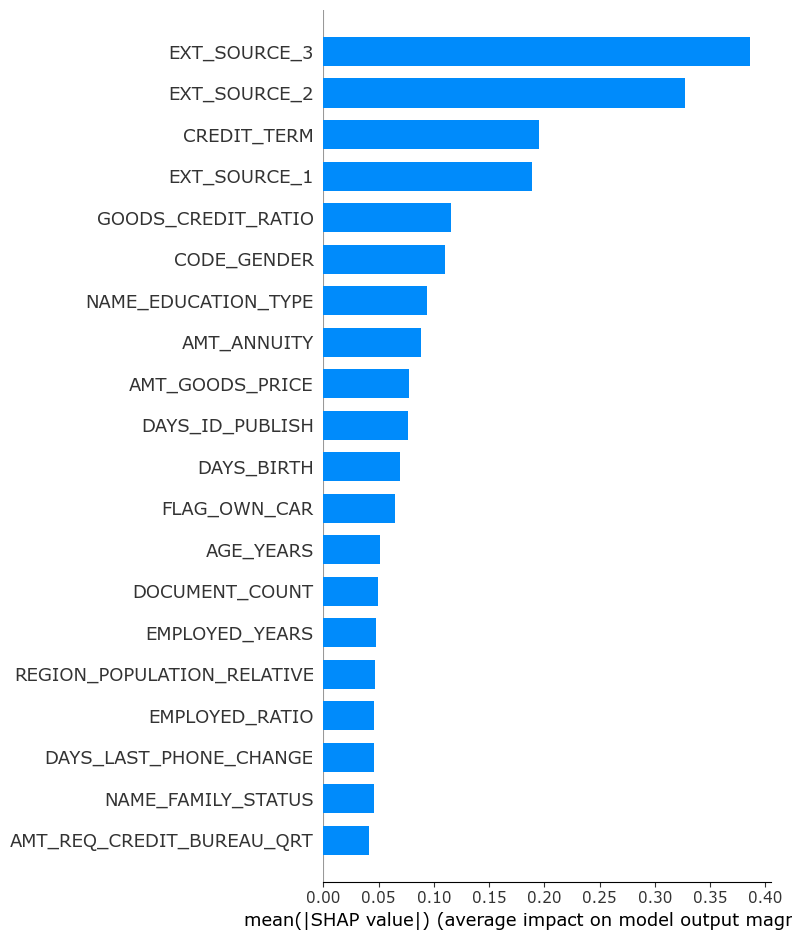

In [7]:
import shap

# Extract final model from pipeline
lgbm_model = model.named_steps['model']

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_sample)

# Handle binary case
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(
    shap_matrix,
    X_sample,
    plot_type="bar",
    max_display=20
)

In [8]:
import shap
shap.initjs()

In [9]:
import shap
import matplotlib.pyplot as plt

%matplotlib inline
shap.initjs()

def explain_decision(customer_idx, threshold=0.30):

    prob = model.predict_proba(X.iloc[[customer_idx]])[:, 1][0]
    decision = "DECLINE" if prob > threshold else "APPROVE"

    print(f"\nCustomer #{customer_idx}")
    print(f"Default Probability: {prob:.1%}")
    print(f"Decision: {decision}")
    print("─" * 50)

    X_fe = fe.transform(X.iloc[[customer_idx]])
    sv = explainer.shap_values(X_fe)

    if isinstance(sv, list):
        shap_values = sv[1][0]
        base_value = explainer.expected_value[1]
    else:
        shap_values = sv[0]
        base_value = explainer.expected_value

    exp = shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=X_fe.iloc[0],
        feature_names=X_fe.columns.tolist()
    )

    shap.plots.waterfall(exp)   # 👈 use new API
    plt.show()                  # 👈 force render

In [10]:
explain_decision(0)

c:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform\venv\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Program Files\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenar


Customer #0
Default Probability: 91.1%
Decision: DECLINE
──────────────────────────────────────────────────


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


ValueError: Failed to find font DejaVu Sans:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0, and fallback to the default font was disabled

<Figure size 800x650 with 3 Axes>